# Zastosowanie wielomianów ortogonalnych w medycynie obliczeniowej


 Użycie wielomianów ortogonalnych do analizy EKG 

Instalacja wymaganych pakietów

In [1]:
using Pkg

In [2]:
Pkg.add("Polynomials")
Pkg.add("SpecialPolynomials")
Pkg.add("Plots")
Pkg.add("CSV")
Pkg.add("DataFrames")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
   Installed Memoize ──────────── v0.4.4
   Installed SpecialPolynomials ─ v0.5.1
    Updating `~/.julia/environments/v1.12/Project.toml`
  [a25cea48] + SpecialPolynomials v0.5.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [c03570c3] + Memoize v0.4.4
  [a25cea48] + SpecialPolynomials v0.5.1
Precompiling packages...
    834.1 ms  ✓ Memoize
   2681.6 ms  ✓ SpecialPolynomials
  2 dependencies successfully precompiled in 4 seconds. 280 already precompiled.
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.t

In [3]:
using Polynomials
using SpecialPolynomials
using Plots
using LinearAlgebra
using CSV
using DataFrames

## Teoria

**Wielomiany ortogonalne** to rodzina wielomianów, w których iloczyn skalarny dwóch róznych wielomianów jest równa 0.

Jeżeli dodatkowo iloczyn skalarny wielomianu "przez siebie" jest równy 1, to nazywamy je **wielomianami ortonormalnymi**

Iloczyn skalarny wielomianów można zdefiniować jako:

$<P_m,P_n>=\int_a^b P_n(x)P_m(x)W(x)dx = 0$

Funkcja *W* jest nazywana *funkcją wagową*.

### Przykładowe rodziny wielomianów ortogonalnych

| Nazwa                | Przedział       | Funkcja wagowa           | Zastosowanie                                           | Parzystość                                                     |
|----------------------|-----------------|--------------------------|--------------------------------------------------------|----------------------------------------------------------------|
| Czebyszewa (1 rzędu) | [-1,1]          | $\frac{1}{\sqrt{1-x^2}}$ | Zera wielomianu jako węzły interpolacji wielomianowej  | Dla parzystego k - parzyste, dla nieparzystego k - nieparzyste |
| Legendre             | [-1,1]          | 1                        | Zera wielomianu jako węzły kwadratur Gaussa-Legendre'a | jw                                                             |
| Hermite              | [$-\infty$,$\infty$] | $\exp(-x^2)$             | Zera wielomianu jako węzły kwadratur Gaussa-Hermite'a  | jw                                                             |
| Laguerre             | [0,$\infty$]      | $\exp(-x)$               | Zera wielomianu jako węzły kwadratur Gaussa-Laguerra'a | brak                                                           |


### Wielomiany Hermite'a

Zdefiniowane są rekurencyjnie jako:

$H_0(x) = 1$

$H_1(x) = 2x$

$H_{n+1}(x) = 2xH_n(x)-2nH_{n-1}$

Wykres przykładowego wielomianu (tutaj 3 stopnia)

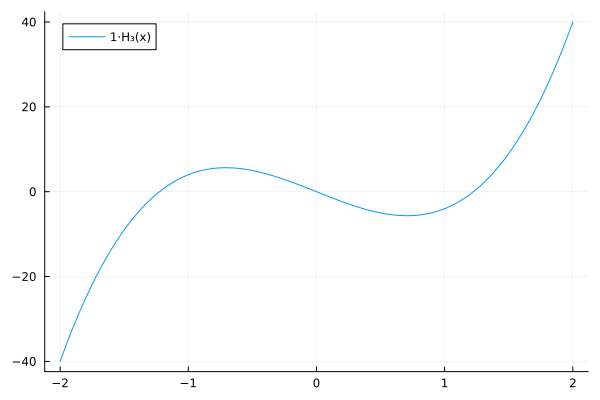

In [4]:
h3 = Hermite([0, 0, 0, 1])
plot(h3, -2, 2)

Żeby nie podawać wektora ze współczynnikami kolejnych stopni, można zrobić inaczej

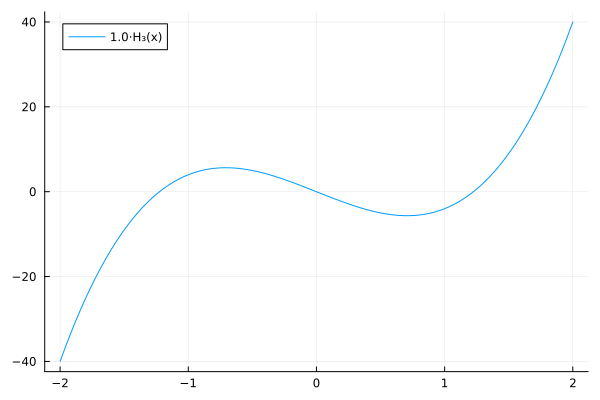

In [5]:
h4 = basis(Hermite, 3)
plot(h4, -2, 2)

### Przykład aproksymacji

Spróbujemy dokonać aproksymacji zaszumionej funkcji `cos` wykorzystując rodzinę wielomianów ortogonalnych Hermite'a.

In [6]:
# Definicja węzłów
xx = -5:0.1:5
yy = cos.(xx/3 .+.2).^2 .+ rand(length(xx))/5;

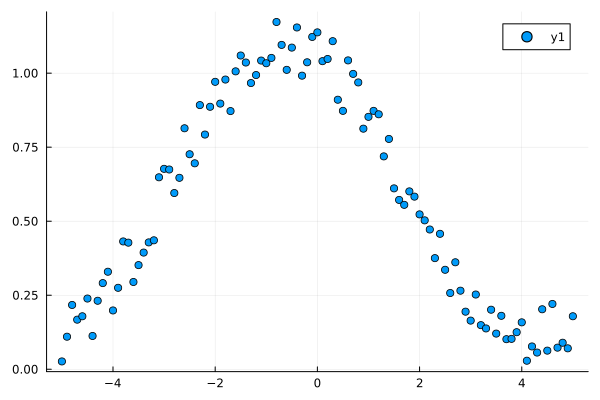

In [7]:
scatter(xx, yy, markershape=:circle)

Obliczony wektor wartości normalizujemy do 1, żeby łatwiej policzyć współczynniki aproksymacji (niżej objaśnienie dlaczego łatwiej). 

In [8]:
#przykład prostego wektora, który znormalizujemy
vec=[2,2,2,2]

4-element Vector{Int64}:
 2
 2
 2
 2

In [9]:
# iloczyn skalarny = długość^2
dot(vec,vec)

16

In [10]:
# normalizacja - długość wektora =1
normalize(vec)

4-element Vector{Float64}:
 0.5
 0.5
 0.5
 0.5

In [11]:
# sprawdzamy długość^2
dot(normalize(vec), normalize(vec))

1.0

* 0bliczamy funkcję bazową uwzględniającą czynnik wagowy.
$<P_m,P_n>=\int_{-\infty}^{\infty} H_n(x)H_m(x)\exp(-x^2)dx 
= \int_{-\infty}^{\infty}\underbrace{H_n(x)\exp(-\frac{x^2}{2})}_{\text{funkcja bazowa}_n}\underbrace{H_m(x)\exp(-\frac{x^2}{2})}_{\text{funkcja bazowa}_m}$

* Wyliczamy jej wartości dla podanych punktów x
* Otrzymany wektor wartości normalizujemy


In [12]:
# obliczamy funkcję bazową
# argument 'norm'  na potrzeby wykresów
function base_fun(k, x, norm=true)
    H_k = basis(Hermite, k).(x)
    app = H_k .* exp.(-(x.^2)/2)
    # normalize to have norm 1
    if norm
        return normalize(app)
    end
    return app
end

base_fun (generic function with 2 methods)

In [13]:
y_2_unnorm = base_fun(2, xx, false);
y_2_norm = base_fun(2, xx);

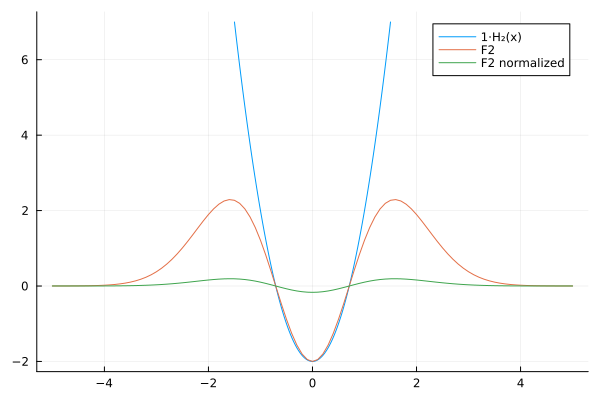

In [14]:
plot(Hermite([0, 0, 1]), -1.5, 1.5)
plot!(xx, y_2_unnorm, label="F2")
plot!(xx, y_2_norm, label="F2 normalized")

Obliczamy wektory wartosci dla punktów w xx dla kilku kolejnych funkcji bazowych

In [15]:
f0 = base_fun(0, xx, true);
f1 = base_fun(1, xx, true);
f2 = base_fun(2, xx, true);
f3 = base_fun(3, xx, true);

Sprawdźmy czy baza jest ortonormalna (uwaga: zamiast liczyć całkę, sprawdzamy po prostu iloczyn skalarny wektorów wartości. Jeśli wartości są wystarczająco "gęsto" jest do dobre przybliżenie).

In [16]:
dot_base = Array{Float64, 2}(undef, 4, 4); 

for (i, f_i) in enumerate([f0, f1, f2, f3]) 
    for (j, f_j) in enumerate([f0, f1, f2, f3])
        dot_base[i,j] = dot(f_i, f_j)
    end
end

In [17]:
dot_base

4×4 Matrix{Float64}:
  1.0           9.17832e-18  -3.25356e-11   1.85612e-18
  9.17832e-18   1.0           1.88742e-17  -9.61163e-10
 -3.25356e-11   1.88742e-17   1.0          -7.22228e-18
  1.85612e-18  -9.61163e-10  -7.22228e-18   1.0

OK, baza jest ortonormalna

Obliczamy kolejne współczynniki aproksymacji. Dzięki ortonormalnej bazie, poszczególne współczynniki są iloczynami skalarnymi wektora wartości funkcji aproksymowanej oraz  wektora bazowego (analogia: rzut  wektora wartości funkcji aproksymowanej w kierunku wektora bazowego).

Wektor bazowy jest znormalizowany $|\vec{j}|=1$, co upraszcza obliczenia.

Analogia w 2D

$\text{rzut }\vec{a} \text{ w kierunku }  \vec{j} =|\vec{a}|\cdot cos(\angle(\vec{a},\vec{j}))=|\vec{a}|\cdot|\vec{j}|\cdot cos(\angle(\vec{a},\vec{j}))=dot(\vec{a},\vec{j})$

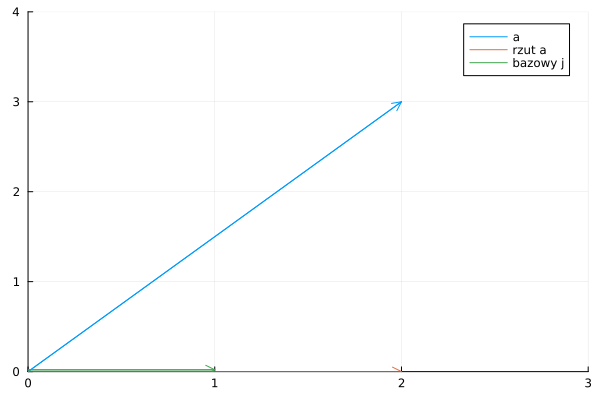

In [18]:
plot([0,2],[0,3],xrange=[0,3], yrange=[0,4],arrow=true, label="a")
plot!([0,2],[0,0],xrange=[0,3], yrange=[0,4],arrow=true, label="rzut a")
plot!([0,1],[0.02,0.02],xrange=[0,3], yrange=[0,4],arrow=true, label="bazowy j")

In [19]:
c0 = dot(yy, f0)
c1 = dot(yy, f1)
c2 = dot(yy, f2)
c3 = dot(yy, f3)
c0, c1, c2, c3

(5.769126403597918, -0.7981285551981617, 2.6562251844601996, -0.8223398526982496)

Liczymy wartości aproksymowane kolejnymi stopniami

In [20]:
y_app_0 = c0*f0;
y_app_1 = c1*f1;
y_app_2 = c2*f2;
y_app_3 = c3*f3;

In [21]:
y_app_01 = y_app_0 + y_app_1;
y_app_012 = y_app_01 + y_app_2;
y_app_0123 = y_app_012 + y_app_3;

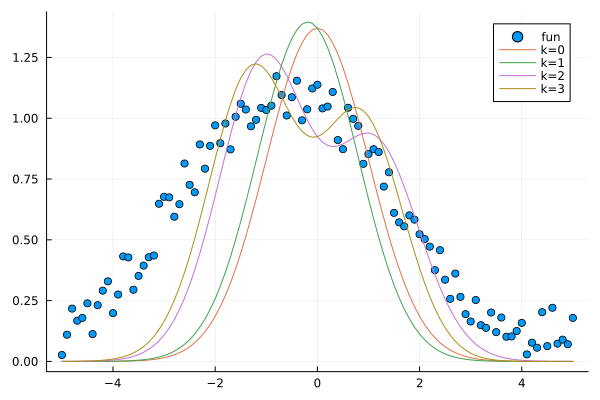

In [22]:
scatter(xx, yy, markershape=:circle, label="fun")
plot!(xx, y_app_0, label="k=0")
plot!(xx, y_app_01, label="k=1")
plot!(xx, y_app_012, label="k=2")
plot!(xx, y_app_0123, label="k=3")

Liczymy błędy aproksymacji kolejnymi stopniami

In [23]:
using Statistics

In [24]:
mse(y1, y2) = mean((y1-y2).^2)

mse (generic function with 1 method)

In [25]:
mse(yy, y_app_0)

0.12513279865740276

In [26]:
mse(yy, y_app_01)

0.11882577696806905

In [27]:
mse(yy, y_app_012)

0.04896902220017024

In [28]:
mse(yy, y_app_0123)

0.04227354859029435

### EKG

Dane pochodzą z bazy https://www.physionet.org/content/mitdb/1.0.0/ .

W sygnale można wyróżnić wiele struktur, z których najbardziej charakterystyczną jest zespół QRS.

In [29]:
ekg_data = CSV.read("ecg_data.csv", DataFrame);

In [30]:
first(ekg_data, 5)

Row,time,signalN,signalV
,Float64,Float64,Float64
1,-0.1,0.0183886,-0.0990972
2,-0.0972222,0.0145191,-0.0920442
3,-0.0944444,0.012849,-0.0831644
4,-0.0916667,0.0124946,-0.0722728
5,-0.0888889,0.0124117,-0.0593656


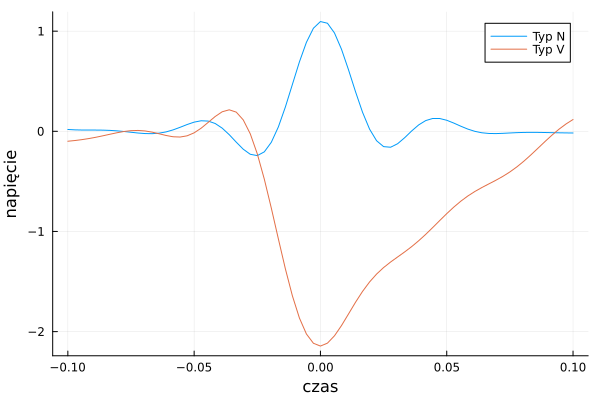

In [31]:
plot(ekg_data.time, ekg_data.signalN, label="Typ N", xlabel = "czas", ylabel="napięcie")
plot!(ekg_data.time, ekg_data.signalV, label="Typ V")

(5.725113911598116, -0.9157906158817669, 2.711325477169205, -0.8018390195854078)

Uwaga: Funkcje bazowe mają pewną "szerokość" i najlepiej aproksymują inne funkcje o podobnej szerokości. Można dodatkowo sparametryzować f. bazowe aby były węższe i lepiej pasowały do zespołów QRS. Na potrzeby laboratorium postąpimy inaczej - przeskalujemy oś X aproksymowanych sygnałów.

In [32]:
# Definicja węzłów
xx_ekg = ekg_data.time*40
yy_ekgV = ekg_data.signalV;

## Zadania

#### Zadanie 1 (1 pkt)

Narysować 6 pierwszych wielomianów Hermita (na jednym wykresie albo siatce 2x3 lub 3x2) $H_m(x)$, $m \in \{0,1,...,5\}$

Podobnie  narysować 6 pierwszych funkcji bazowych z uwzględnieniem czynnika wagowego $H_m(x)\exp(-\frac{x^2}{2})$, $m \in \{0,1,...,5\}$

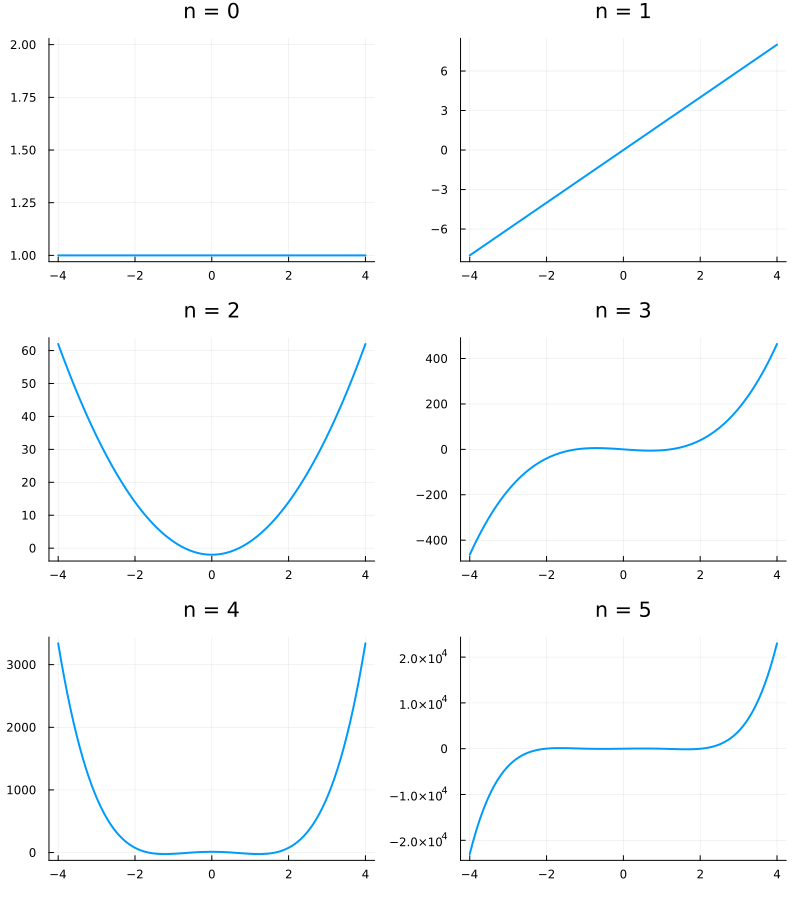

In [42]:
# Hermite Polynomials
subplots = []
h_vec = []

for i in 0:5
    h_m = basis(Hermite, i)
    push!(h_vec, h_m)
    
    p = plot(h_m, -4, 4, 
             title = "n = $i", 
             linewidth = 2, 
             legend = false)
             
    push!(subplots, p)
end

grid = plot(subplots..., layout = (3, 2), size = (800, 900))

display(grid)

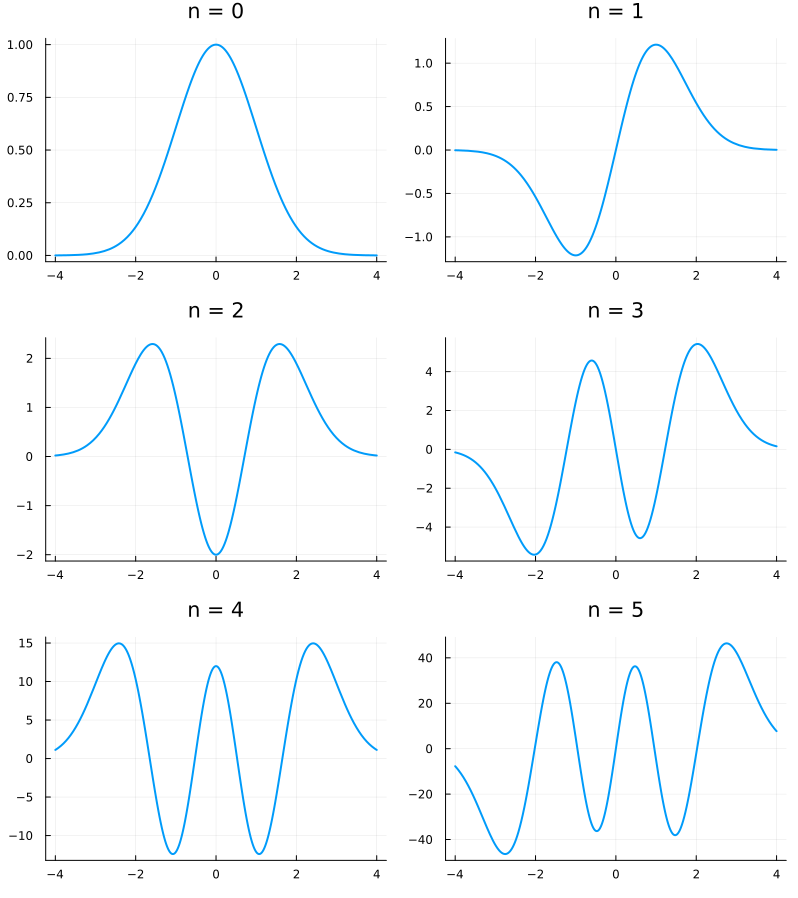

In [41]:
# Hermite Polynomials with Weight Function
subplots = []
h_weighted_vec = []

for i in 0:5
    h_m = basis(Hermite, i)
    weighted_h = x -> h_m(x) * exp(-x^2 / 2)
    push!(h_weighted_vec, weighted_h)
    
    p = plot(weighted_h, -4, 4, 
             title = "n = $i", 
             linewidth = 2, 
             legend = false)
             
    push!(subplots, p)
end

grid = plot(subplots..., layout = (3, 2), size = (800, 900))

display(grid)

#### Zadanie 2 (1 pkt)

Pokazać, że same wielomiany nie są ortogonane, ale już z funkcją wagową $exp(-x^2)$ są. Uzyć metody z wektorami wartości, założyć pewien przedział.

In [116]:
function checkOrthogonality(h_vec)
    xs = range(-6, 6, length=1000)
    
    h_evaluated = [normalize(h.(xs)) for h in h_vec]
    
    n = length(h_vec)
    dot_base = Matrix{Float64}(undef, n, n) 
    
    for (i, h_i) in enumerate(h_evaluated) 
        for (j, h_j) in enumerate(h_evaluated)
            dot_base[i,j] = dot(h_i, h_j)
        end
    end
    
    return round.(dot_base, digits=10)
end

checkOrthogonality (generic function with 2 methods)

In [117]:
dot_base_h = checkOrthogonality(h_vec)

6×6 Matrix{Float64}:
  1.0       -0.0        0.731092  -0.0       0.579633  0.0
 -0.0        1.0       -0.0        0.905395  0.0       0.797866
  0.731092  -0.0        1.0        0.0       0.951706  0.0
 -0.0        0.905395   0.0        1.0       0.0       0.97007
  0.579633   0.0        0.951706   0.0       1.0       0.0
  0.0        0.797866   0.0        0.97007   0.0       1.0

In [115]:
dot_base_h_weighted = checkOrthogonality(h_weighted_vec)

6×6 Matrix{Float64}:
  1.0  -0.0  -0.0  -0.0  -0.0   0.0
 -0.0   1.0  -0.0  -0.0   0.0  -0.0
 -0.0  -0.0   1.0   0.0  -0.0  -0.0
 -0.0  -0.0   0.0   1.0   0.0  -0.0
 -0.0   0.0  -0.0   0.0   1.0   0.0
  0.0  -0.0  -0.0  -0.0   0.0   1.0

#### Zadanie 3  (1 pkt)

Dokonać aproksymacji zespołu QRS typu N oraz V za pomocą kilku kolejnych stopni. Przedstawić osobno wykresy dla N i V.

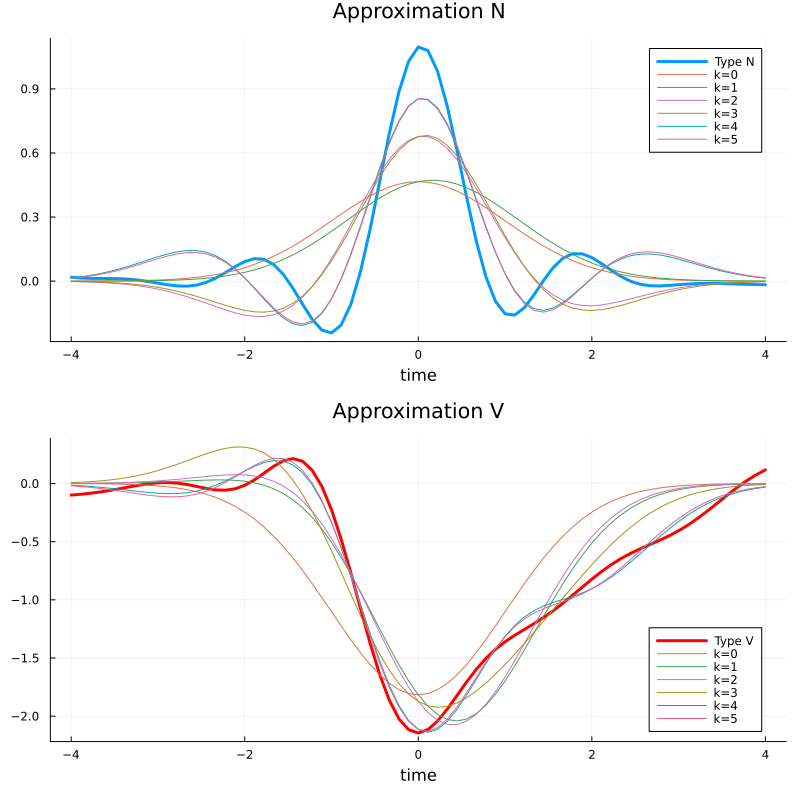

In [138]:
n = 5

p_v = plot(xx_ekg, yy_ekgV, label="Type V", lw=3, color="red", title="Approximation V")
y_sum_v = zeros(length(xx_ekg))

for k in 0:n
    fk = normalize(basis(Hermite, k).(xx_ekg) .* exp.(-(xx_ekg.^2)/2))
    ck = dot(yy_ekgV, fk) # 
    y_sum_v += ck * fk
    plot!(p_v, xx_ekg, y_sum_v, label="k=$k")
end

yy_ekgN = ekg_data.signalN
p_n = plot(xx_ekg, yy_ekgN, label="Type N", lw=3, title="Approximation N")
y_sum_n = zeros(length(xx_ekg))

for k in 0:n
    fk = normalize(basis(Hermite, k).(xx_ekg) .* exp.(-(xx_ekg.^2)/2))
    ck = dot(yy_ekgN, fk)
    y_sum_n += ck * fk
    plot!(p_n, xx_ekg, y_sum_n, label="k=$k")
end



plot(p_n, p_v, layout=(2,1), size=(800, 800), xlabel="time")

#### Zadanie 4  (1 pkt)

Przedstawić wykres błędu aproksymacji w zależności od stopnia wielomianu dla stopni od 0 do 10. Jakiego stopnia należy użyć gdybyśmy mieli robić coś dalej z rezultatem aproksymacji?

In [131]:
using Statistics

n = 10
println("Approximation errors for Type V:")
y_sum_v = zeros(length(xx_ekg))
errors_v = []

for k in 0:n
    fk = normalize(basis(Hermite, k).(xx_ekg) .* exp.(-(xx_ekg.^2)/2))
    ck = dot(yy_ekgV, fk)
    y_sum_v += ck * fk
    
    current_mse = mse(yy_ekgV, y_sum_v)
    push!(errors_v, current_mse)
    
    println("k=$k: MSE = $current_mse")
end

println("\n" * "-"^30 * "\n")

println("Approximation errors for Type N:")
y_sum_n = zeros(length(xx_ekg))
errors_n = []

for k in 0:n
    fk = normalize(basis(Hermite, k).(xx_ekg) .* exp.(-(xx_ekg.^2)/2))
    ck = dot(yy_ekgN, fk)
    y_sum_n += ck * fk
    
    current_mse = mse(yy_ekgN, y_sum_n)
    push!(errors_n, current_mse)
    
    println("k=$k: MSE = $current_mse")
end

# Take k = 10

Approximation errors for Type V:
k=0: MSE = 0.1675380359890898
k=1: MSE = 0.06205879347269694
k=2: MSE = 0.060652867414550976
k=3: MSE = 0.04008843785445875
k=4: MSE = 0.006383463796395045
k=5: MSE = 0.006081291954185556
k=6: MSE = 0.005854964251436245
k=7: MSE = 0.003471290140341321
k=8: MSE = 0.0032469317824282587
k=9: MSE = 0.0005892396935529139
k=10: MSE = 0.0005655614018863204

------------------------------

Approximation errors for Type N:
k=0: MSE = 0.05653083118425804
k=1: MSE = 0.055816908933032455
k=2: MSE = 0.03630893116640521
k=3: MSE = 0.0361317602745503
k=4: MSE = 0.017944119544999304
k=5: MSE = 0.017906033228894835
k=6: MSE = 0.00529813900848142
k=7: MSE = 0.00520028825331861
k=8: MSE = 0.000704073888372569
k=9: MSE = 0.0007045246082865523
k=10: MSE = 0.0001460905557721477


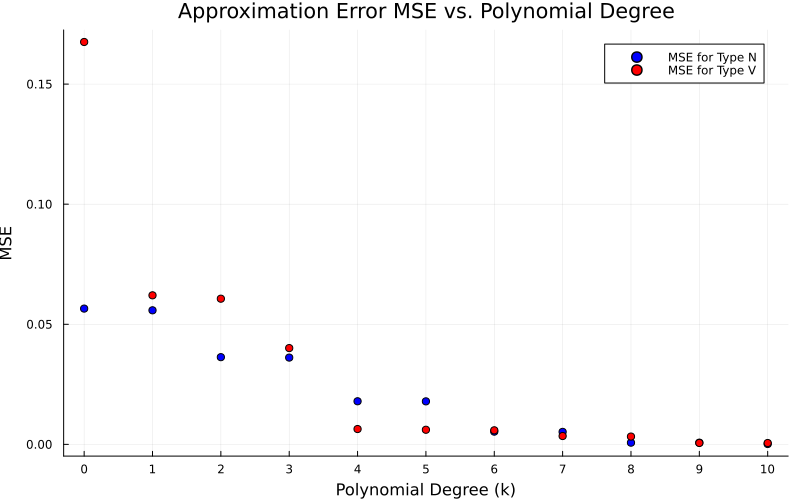

In [132]:
# Plot
using Plots

scatter(0:n, errors_n, 
    label="MSE for Type N", 
    marker=:circle, 
    lw=2, 
    color=:blue)

scatter!(0:n, errors_v, 
    label="MSE for Type V", 
    marker=:circle, 
    lw=2, 
    color=:red)

scatter!(
    title="Approximation Error MSE vs. Polynomial Degree",
    xlabel="Polynomial Degree (k)",
    ylabel="MSE",
    xticks=0:n,
    grid=true,
    size=(800, 500)
)

# Take k = 10